# Visualizing results temporally

### Imports and data loading

In [2]:
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Transformer
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.transforms as mtr

plt.rcParams.update({'font.size': 18})

In [21]:
## CHOOSE RUNS TO USE HERE
model_type = 'unet' 
run_nbrs = ['03']
compare_w_swin2sr = True
sea_masking = False

data_path = "../data/CERRA-ERA5/test_samples/"
pred_paths = [f"./runs_{model_type}/run_{run_nbr}/inference_results/" for run_nbr in run_nbrs]
lsm_path = "../data/CERRA-ERA5/cerra_const_sfc_variables.nc4c"

if compare_w_swin2sr:
    swin2sr_path = "../../hortense_dmidata/run_18/"
    swin2sr = []
    era5 = []

preds = []
cerra = []

for year in range(2015, 2021):
    print(f'Loading year {year}...')

    pred = []
    for pred_path in pred_paths:
        print(f'Loading data from {pred_path}...')
        ds = xr.open_dataset(pred_path + f'{model_type}_{year}.nc4c', engine='netcdf4')
        pred.append(ds['predictions'])
    preds.append(xr.concat(pred, dim='model'))

    print(f'Loading data from CERRA...')
    ds = xr.open_dataset(data_path + f'cerra_samples_{year}.nc4c', engine='netcdf4')
    cerra.append(ds['2t'])

    if compare_w_swin2sr:
        print(f'Loading data from ERA5...')
        ds = xr.open_dataset(data_path + f'era5_samples_{year}.nc4c', engine='netcdf4')
        era5.append(ds['2t'])

        print(f'Loading data from Swin2SR...')
        for month in range(1, 13):
            ds = xr.open_dataset(swin2sr_path + f'prediction_{year}-{month:02d}_remapped.nc', engine='netcdf4')
            swin2sr.append(ds['prediction'])

preds = xr.concat(preds, dim='time')
cerra = xr.concat(cerra, dim='time')

if compare_w_swin2sr:
    swin2sr = xr.concat(swin2sr, dim='time')
    era5 = xr.concat(era5, dim='time')


# Convert from Kelvin to Celsius
preds = preds - 273.15
cerra = cerra - 273.15

if compare_w_swin2sr:
    swin2sr = swin2sr - 273.15
    era5 = era5 - 273.15
    era5 = era5.resample(time='D').mean()

# Homogenize dimensions
cerra = cerra.isel(height=0)
cerra = cerra.resample(time='D').mean()
preds = preds.resample(time='D').mean()
preds = preds.rename({'height':'y', 'width':'x'})
preds['x'] = preds.x * 5500.
preds['y'] = preds.y * 5500.

# Only one variable to use here
preds = preds[:].sel(channel=0)


Loading year 2015...
Loading data from ./runs_unet/run_03/inference_results/...
Loading data from CERRA...
Loading data from ERA5...
Loading data from Swin2SR...
Loading year 2016...
Loading data from ./runs_unet/run_03/inference_results/...
Loading data from CERRA...
Loading data from ERA5...
Loading data from Swin2SR...
Loading year 2017...
Loading data from ./runs_unet/run_03/inference_results/...
Loading data from CERRA...
Loading data from ERA5...
Loading data from Swin2SR...
Loading year 2018...
Loading data from ./runs_unet/run_03/inference_results/...
Loading data from CERRA...
Loading data from ERA5...
Loading data from Swin2SR...
Loading year 2019...
Loading data from ./runs_unet/run_03/inference_results/...
Loading data from CERRA...
Loading data from ERA5...
Loading data from Swin2SR...
Loading year 2020...
Loading data from ./runs_unet/run_03/inference_results/...
Loading data from CERRA...
Loading data from ERA5...
Loading data from Swin2SR...


In [31]:
truth = cerra
name_truth = 'CERRA'
color_truth = 'black'
sea_masking = True

# If comparing with Swin2SR, remove all additionnal data
if compare_w_swin2sr:
    truth = xr.where(swin2sr.isnull(), np.nan, truth)
    models = [era5, preds[0], swin2sr]
    nb_models = len(models)
    for i in range(nb_models - 1):
        models[i] = xr.where(swin2sr.isnull(), np.nan, models[i])
    name_models = ['ERA5', 'U-Net', 'Swin2SR']
    color_models = ['slategrey', 'orange', 'royalblue']
else:
    models = [preds.isel(model=i) for i in range(len(preds))]
    nb_models = len(models)
    name_models = ['Baseline', 'Land', 'Weighted', 'Full']
    color_models = ['slategrey', 'springgreen', 'coral', 'orchid']

# Apply sea-mask if relevant
if sea_masking:
    lsm = xr.open_dataset(lsm_path, engine='netcdf4')["lsm"]
    truth = xr.where(lsm.squeeze().expand_dims({'time': truth.time}) < .01, np.nan, truth)
    for i in range(nb_models):
        models[i] = xr.where(lsm.squeeze().expand_dims({'time': truth.time}) < .01, np.nan, models[i])

# If comparing with Swin2SR, crop spatial domain
if compare_w_swin2sr:
    truth = truth[:, 40:215, 60:215]
    for i in range(nb_models):
        models[i] = models[i][:, 40:215, 60:215]


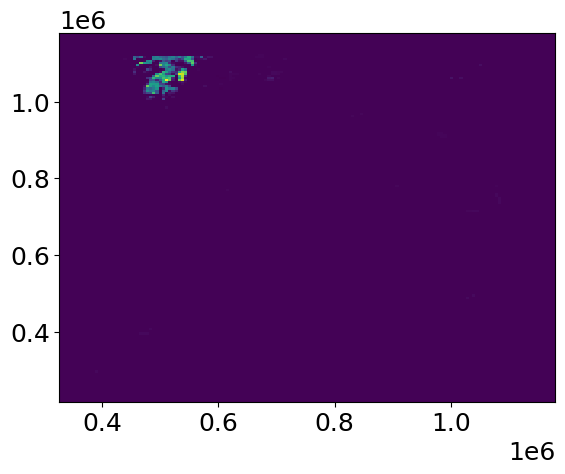

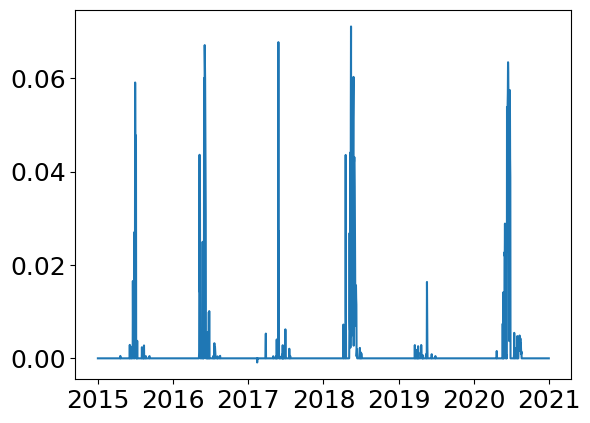

In [33]:
# Quickly: where and when are the highest residuals for each model?
m = 2
highest_errors = models[m].where((np.abs(models[m]-truth) > 7) & (truth > 0) & (truth < 20), 0)
spatially = highest_errors.mean(dim='time')
plt.pcolormesh(spatially.x, spatially.y, spatially.values)
plt.show()
temporally = highest_errors.mean(dim='x').mean(dim='y')
plt.plot(temporally.time, temporally.values)
plt.show()

## Whole domain

### Distribution of Tmax

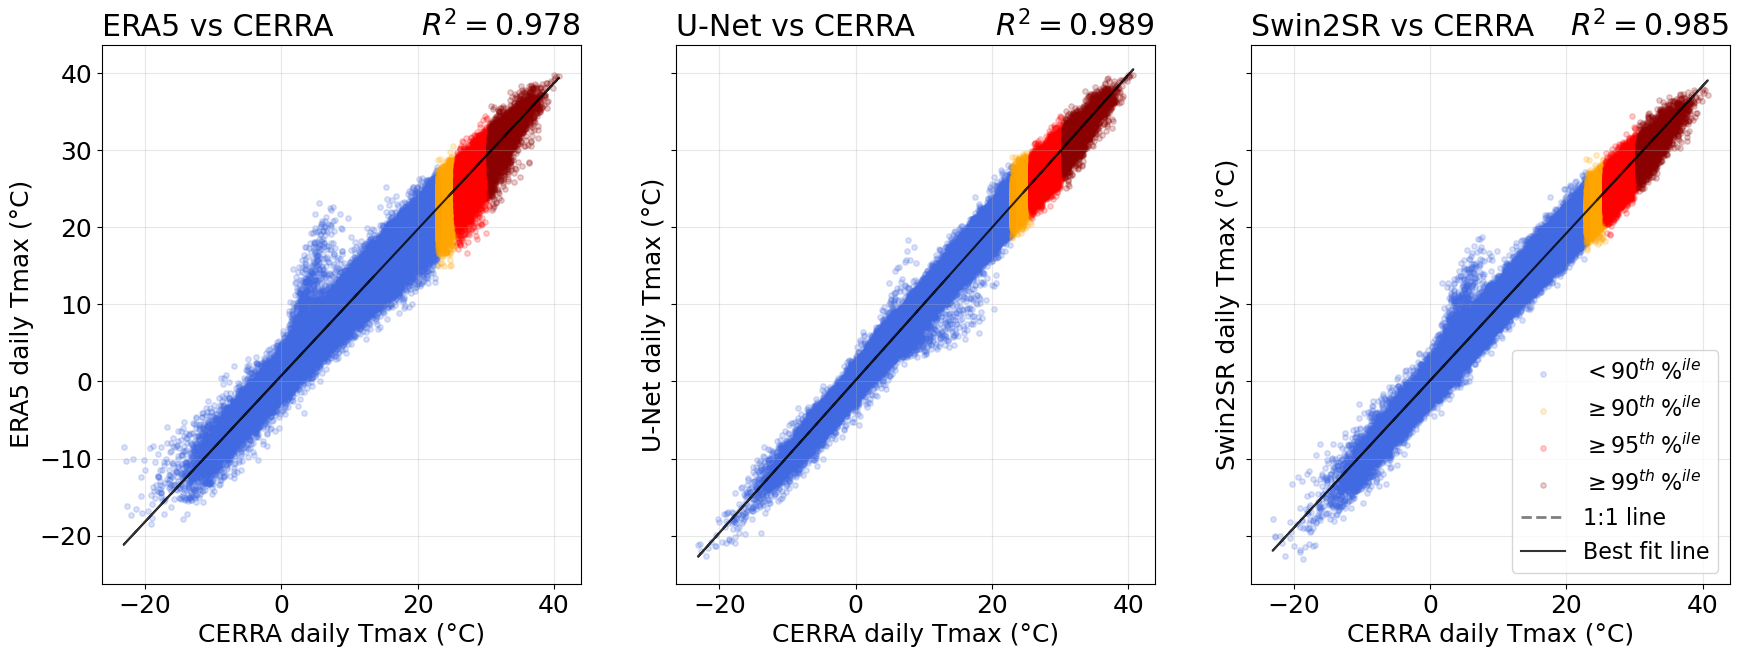

In [34]:
flat_truth = truth.values.flatten()
random_ids = np.random.choice(np.arange(len(flat_truth))[~np.isnan(flat_truth)], 595000,replace=False)
flat_truth_s = flat_truth[random_ids]
flat_models = [flat_truth_s] + [models[i].values.flatten()[random_ids] for i in range(nb_models)]

tmaxlow = [flat_models[i][flat_truth_s < np.quantile(flat_truth_s, 0.9)] for i in range(nb_models+1)]
tmax90 = [flat_models[i][(flat_truth_s >= np.quantile(flat_truth_s, 0.9)) & (flat_truth_s < np.quantile(flat_truth_s, 0.95))] for i in range(nb_models+1)]
tmax95 = [flat_models[i][(flat_truth_s >= np.quantile(flat_truth_s, 0.95)) & (flat_truth_s < np.quantile(flat_truth_s, 0.99))] for i in range(nb_models+1)]
tmax99 = [flat_models[i][flat_truth_s >= np.quantile(flat_truth_s, 0.99)] for i in range(nb_models+1)]

fig, axs = plt.subplots(1, nb_models, figsize=(nb_models * 7, 7), sharey=True)

for i in range(nb_models):
        r2 = np.corrcoef(flat_truth_s, flat_models[i+1])[0, 1]**2
        ax = axs[i]
        ax.scatter(tmaxlow[0], tmaxlow[i+1], alpha=0.2, s=15, label='$< 90^{th}\:\%^{ile}$', c='royalblue')
        ax.scatter(tmax90[0], tmax90[i+1], alpha=0.2, s=15, label='$\geq 90^{th}\:\%^{ile}$', c='orange')
        ax.scatter(tmax95[0], tmax95[i+1], alpha=0.2, s=15, label='$\geq 95^{th}\:\%^{ile}$', c='red')
        ax.scatter(tmax99[0], tmax99[i+1], alpha=0.2, s=15, label='$\geq 99^{th}\:\%^{ile}$', c='darkred')
        # Plotting values with more than 7 degrees error separately
        # ax.scatter(flat_truth_s[(np.abs(flat_models[i+1] - flat_truth_s) > 7) & (flat_truth_s > 0) & (flat_truth_s < 20)], 
        #            flat_models[i+1][(np.abs(flat_models[i+1] - flat_truth_s) > 7) & (flat_truth_s > 0) & (flat_truth_s < 20)], 
        #            color='green', s=15, label='> 7° error')
        ax.set_xlabel(f'{name_truth} daily Tmax (°C)')
        ax.set_ylabel(f'{name_models[i]} daily Tmax (°C)')
        ax.set_title(f'{name_models[i]} vs {name_truth}', loc='left')
        ax.set_title(f'$R^2={r2:.3f}$', loc='right')
        ax.grid(True, alpha=0.3)
        # 1:1 line
        lims = [min(flat_truth.min(), flat_models[i+1].min()),
                max(flat_truth.max(), flat_models[i+1].max())]
        ax.plot(lims, lims, '--', color=color_truth, alpha=0.5, linewidth=2, label='1:1 line')
        # Best fit line
        b, a = np.polyfit(flat_truth_s, flat_models[i+1], 1)
        ax.plot(flat_truth_s, a + b * flat_truth_s, 'k-', alpha=0.8, label='Best fit line')
        if i==nb_models-1: ax.legend(fontsize=16, loc='lower right')

plt.show()

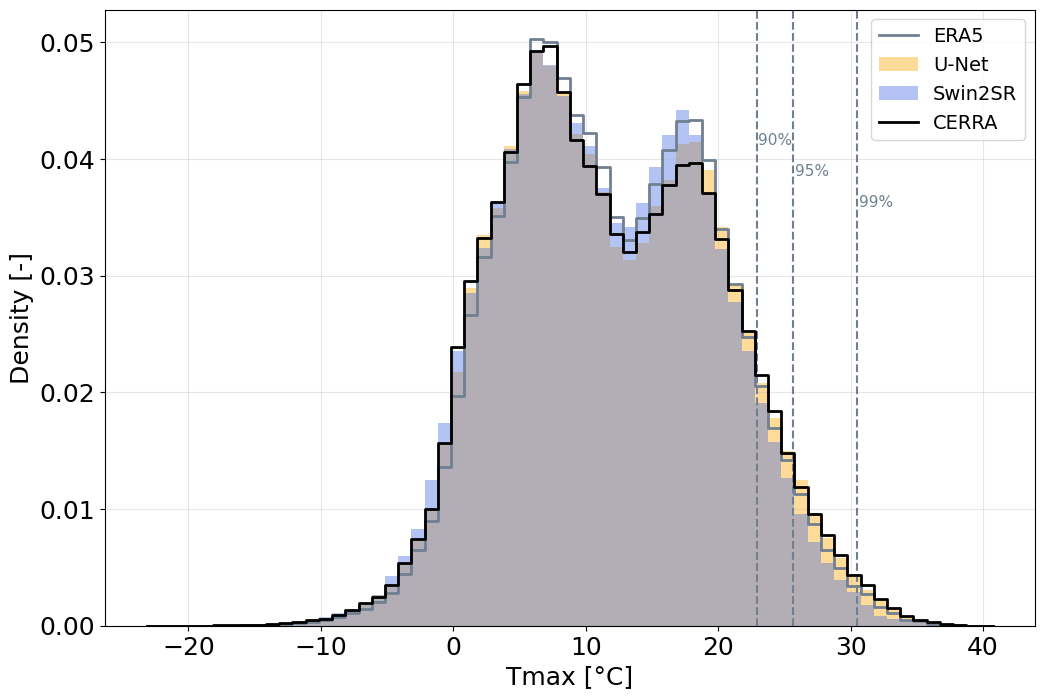

In [35]:
fig, ax = plt.subplots(figsize=(12, 8))

# fig.set_facecolor('none')
# fig.set_alpha(0.0)

# For histplot
bmin, bmax = flat_models[0].min(), flat_models[0].max()

thresholds = [.9, .95, .99]
for i, t in enumerate(thresholds):
    value = np.quantile(flat_truth_s, t)
    ax.axvline(x=value, ls='--', color='slategrey')
    trans = mtr.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(x=value+0.1, y=.8-.05*i, s=str(int(t*100))+'%', c='slategrey', ha='left', va='top', fontsize=11, transform=trans)

for i in range(nb_models):
    sns.histplot(data=flat_models[i+1], stat='density', binwidth=1, binrange=(bmin, bmax), color=color_models[i], 
                 element='step', alpha=.4 if i!=0 else 1, lw=0 if i!=0 else 2, fill=i!=0, label=name_models[i])
    # sns.kdeplot(data=flat_models[i+1], ax=ax, color=color_models[i], label=name_models[i], lw=1 if i==0 else 2, ls='--' if i==0 else '-')
    # ax.axvline(x=flat_models[i+1].mean(), ls='--', color=color_models[i])

sns.histplot(data=flat_models[0], stat='density', binwidth=1, binrange=(bmin, bmax), element='step', lw=2, color=color_truth, fill=False, label=name_truth)
# sns.kdeplot(flat_models[0], ax=ax, color=color_truth, label=name_truth, lw=2)
# ax.axvline(x=flat_models[0].mean(), ls='--', color=color_truth)

# ax.set_title('Daily Tmax distributions and means')
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Tmax [°C]')
ax.set_ylabel('Density [-]')

plt.show()

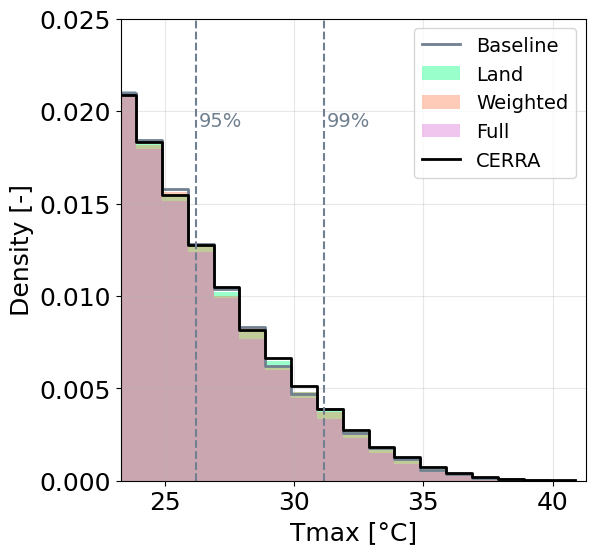

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

for i in range(nb_models):
    sns.histplot(data=flat_models[i+1], stat='density', binwidth=1, binrange=(bmin, bmax), color=color_models[i], element='step', alpha=.4 if i!=0 else 1, lw=0 if i!=0 else 2, fill=i!=0, label=name_models[i])
    # sns.kdeplot(data=flat_models[i+1], ax=ax, color=color_models[i], label=name_models[i], lw=1 if i==0 else 2, ls='--' if i==0 else '-')
    # ax.axvline(x=flat_models[i+1].mean(), ls='--', color=color_models[i])

sns.histplot(data=flat_models[0], stat='density', binwidth=1, binrange=(bmin, bmax), element='step', lw=2, fill=False, color=color_truth, label=name_truth)
# sns.kdeplot(flat_models[0], ax=ax, color=color_truth, label=name_truth, lw=2)
# ax.axvline(x=flat_models[0].mean(), ls='--', color=color_truth)

# ax.set_title('Tmax distributions tails (> $90^{th}$ percentile)')
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Tmax [°C]')
ax.set_ylabel('Density [-]')
ax.set_xlim(np.quantile(flat_truth_s, .9), 1.01*max(flat_truth_s))
ax.set_ylim(0, .025) # Adjust by hand

thresholds = [.95, .99]
for t in thresholds:
    value = np.quantile(flat_truth_s, t)
    ax.axvline(x=value, ls='--', color='slategrey')
    ax.text(x=value + 0.1, y=ax.get_ylim()[1]*.8, s=str(int(t*100))+'%', c='slategrey', ha='left', va='top', fontsize=14)

plt.show()

### Distribution of residuals

In [10]:
diff_models = [flat_models[i+1] - flat_truth_s for i in range(nb_models)]
mae_models = [np.abs(flat_models[i+1] - flat_truth_s) for i in range(nb_models)]

metrics = [diff_models, mae_models]
name_metrics = ['Mean difference', 'MAE']
nb_metrics = len(metrics)

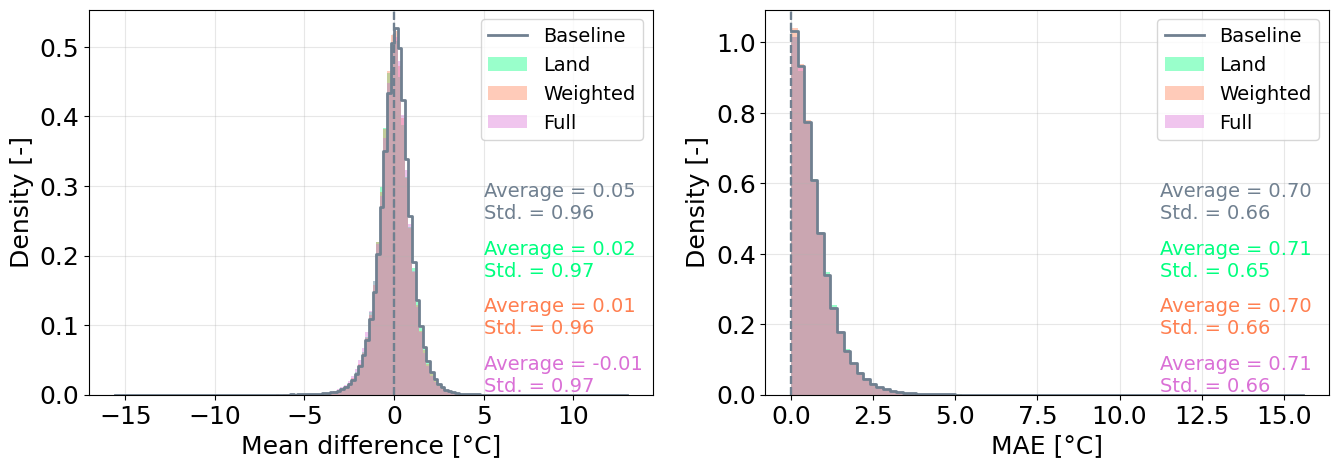

In [11]:
fig, axs = plt.subplots(1, nb_metrics, figsize=(8*nb_metrics, 5))

# For histplot
bmin, bmax = [metrics[i][0].min() for i in range(nb_metrics)], [metrics[i][0].max() for i in range(nb_metrics)]

for i in range(nb_metrics):
    ax = axs[i]
    for j in range(nb_models):
        sns.histplot(data=metrics[i][j], ax=ax, stat='density', binwidth=.2, binrange=(bmin[i], bmax[i]), 
                     color=color_models[j], element='step', alpha=.4 if j!=0 else 1, lw=0 if j!=0 else 2, fill=j!=0, label=name_models[j])
        # sns.kdeplot(data=metrics[i][j], ax=ax, color=color_models[j], label=name_models[j], lw=1 if j==0 else 2, ls='--' if j==0 else '-')
        avg = metrics[i][j].mean()
        std = metrics[i][j].std()
        # ax.axvline(x=avg, ls='--', color=color_models[j])
        ax.text(x=.7, y=.5-.15*j, s=f'Average = {avg:.2f}\nStd. = {std:.2f}', c=color_models[j], ha='left', va='center', fontsize=14, transform=ax.transAxes)
        ax.axvline(x=0, ls='--', color='slategrey')
    # ax.set_title(name_metrics[i])
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(name_metrics[i] + ' [°C]')
    ax.set_ylabel('Density [-]')

### Timeseries

In [36]:
# Compute daily max Tmax over the domain

ts_truth = truth.max(dim='x').max(dim='y')
ts = xr.concat([ts_truth] + [models[i].max(dim='x').max(dim='y') for i in range(nb_models)], dim='model')

years = range(2015, 2021)
nb_years = len(years)

summer_times = [slice(f'{year}-05-15', f'{year}-09-15') for year in years]


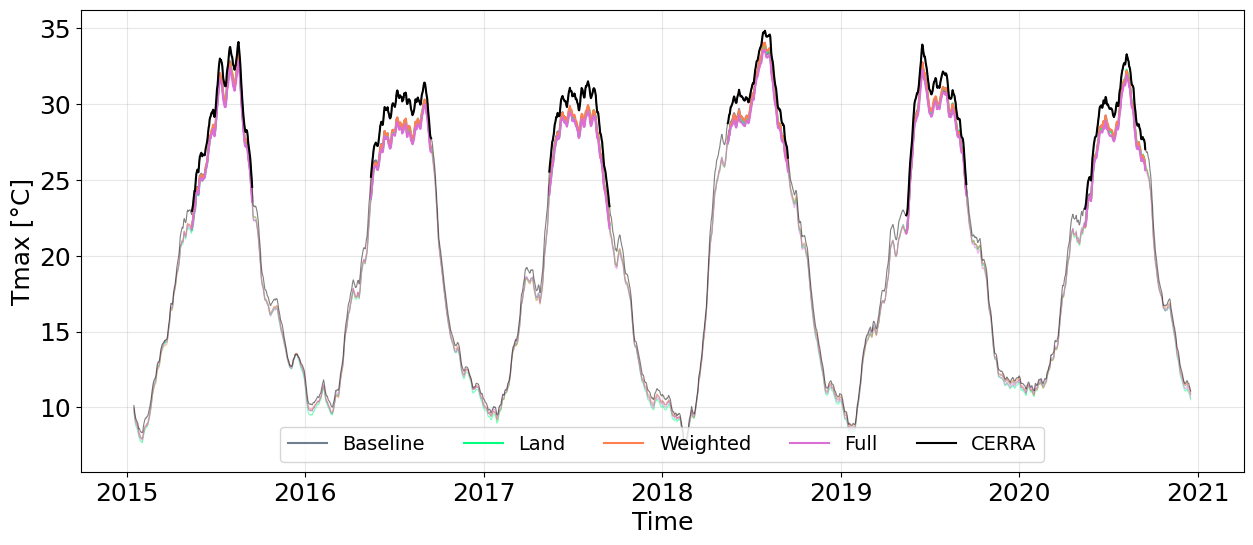

In [13]:
rolling = 30
fig, ax = plt.subplots(figsize=(15,6))


for i in range(nb_models):
    ax.plot(ts.time, ts[i+1].rolling(time=rolling, center=True).mean(), color=color_models[i], alpha=.5, lw=.8)
    # ax.plot(ts.time, ts[i+1].rolling(time=365, center=True).mean(), color=color_models[i], linestyle='--')
    for k in range(nb_years):
        ax.plot(ts.sel(time=summer_times[k]).time, ts[i+1].rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), color=color_models[i], label=name_models[i] if k==0 else None)

ax.plot(ts.time, ts[0].rolling(time=rolling, center=True).mean(), color=color_truth, alpha=.5, lw=.8)
for k in range(nb_years):
    ax.plot(ts.sel(time=summer_times[k]).time, ts[0].rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), color=color_truth, label=name_truth if k==0 else None)
    # ax.plot(ts.time, ts[0].rolling(time=365, center=True).mean(), linestyle='--', color=color_truth)


# ax.set_title(f'Daily max Tmax over domain ({rolling}- and 365-day rolling mean)')
ax.set_xlabel('Time')
ax.set_ylabel('Tmax [°C]')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=14, loc='lower center', ncols=nb_models+1)

plt.show()

In [37]:
ts_diffs, ts_maes = [], []
for model in models:
    ts_diff = (model - truth).mean(dim='x').mean(dim='y')
    ts_mae = np.abs(model - truth).mean(dim='x').mean(dim='y')
    ts_diffs.append(ts_diff)
    ts_maes.append(ts_mae)
ts_diffs = xr.concat(ts_diffs, dim='model')
ts_maes = xr.concat(ts_maes, dim='model')

ts_metrics = xr.concat([ts_diffs, ts_maes], dim='metric')
name_metrics = ['Mean difference', 'MAE']
nb_metrics = len(ts_metrics)

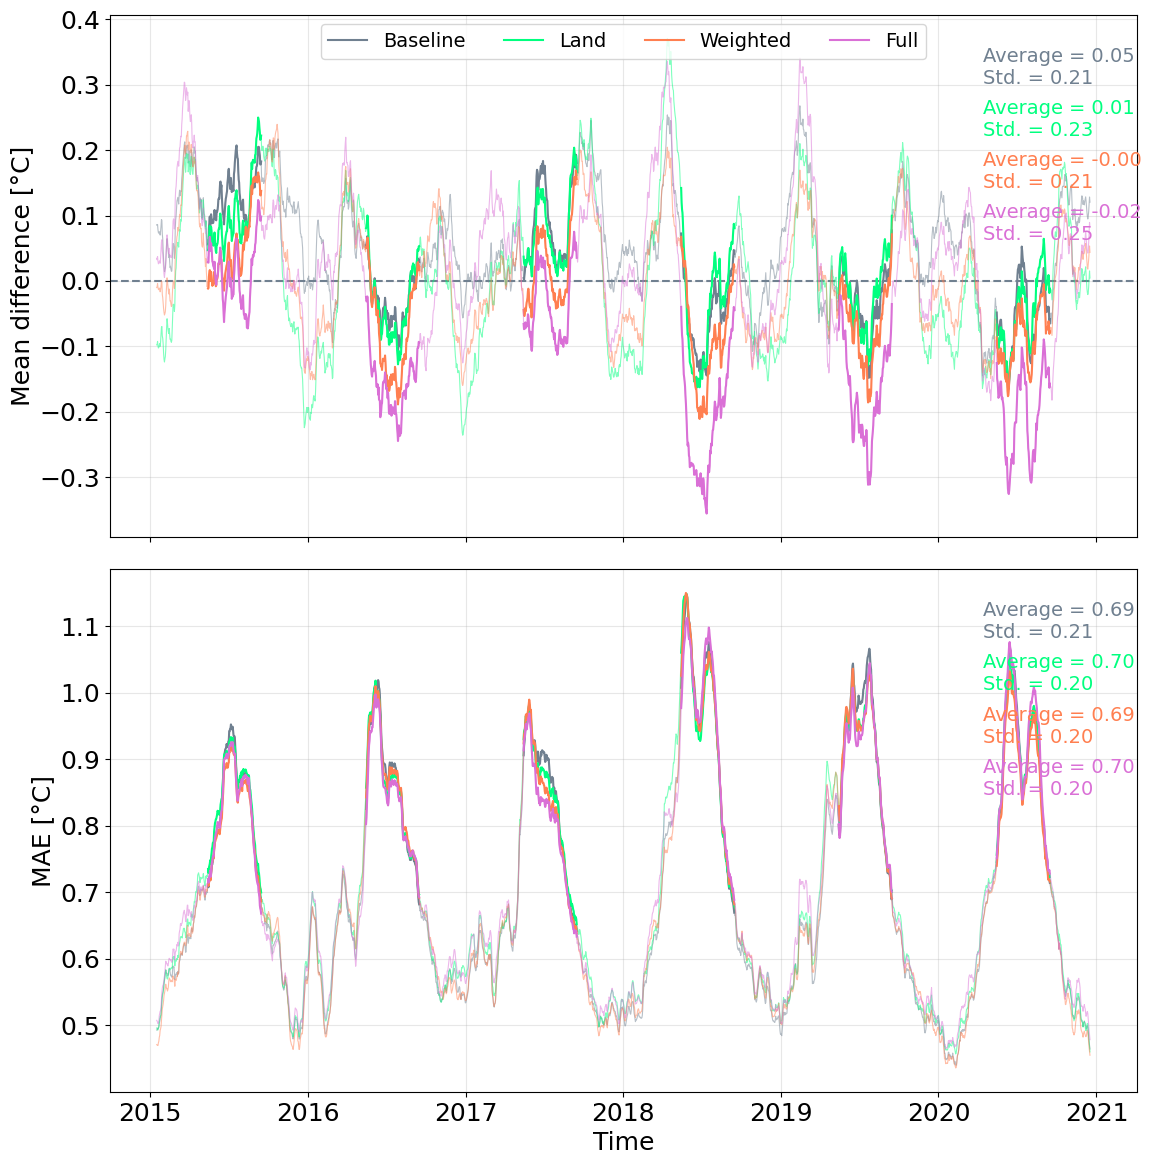

In [ ]:
rolling = 30

fig, axs = plt.subplots(nb_metrics, 1, figsize=(12, 6*nb_metrics), sharex=True)

axs[0].axhline(y=0, color='slategrey', linestyle='--')
for i in range(nb_metrics):
    ax = axs[i]
    for j in range(nb_models):
        ax.plot(ts.time, ts_metrics[i][j].rolling(time=rolling, center=True).mean(), color=color_models[j], alpha=.5, lw=.8)
        # ax.text(x=.85, y=.9-.1*j, s=f'Average = {ts_metrics[i][j].mean():.2f}\nStd. = {ts_metrics[i][j].std():.2f}', c=color_models[j], ha='left', va='center', fontsize=14, transform=ax.transAxes)
        for k in range(nb_years):
            if i == 0 and k == 0:
                ax.plot(ts.sel(time=summer_times[k]).time, ts_metrics[i][j].rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), color=color_models[j], label=name_models[j])
            else:
                ax.plot(ts.sel(time=summer_times[k]).time, ts_metrics[i][j].rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), color=color_models[j])
    # ax.set_title(f'{name_metrics[i]} over domain ({rolling}-day rolling mean)')
    if i==0: ax.legend(fontsize=14, loc='upper center', ncols=nb_models)
    ax.grid(True, alpha=0.3)
    if i==nb_metrics-1: ax.set_xlabel('Time')
    ax.set_ylabel(name_metrics[i] + ' [°C]')

plt.tight_layout()
plt.show()

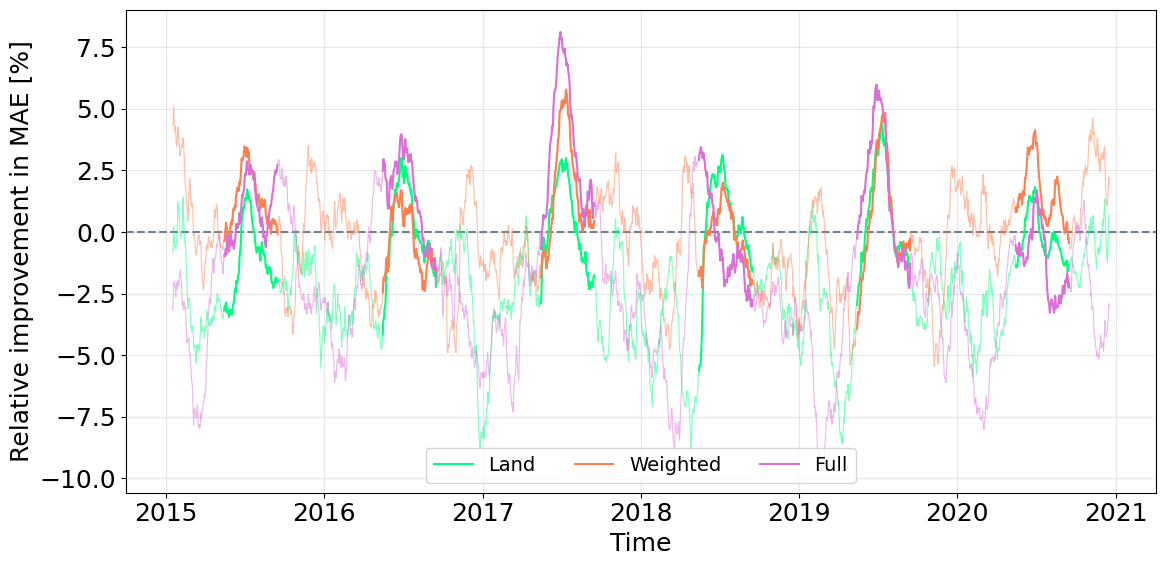

In [ ]:
rolling = 30

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.axhline(y=0, color='slategrey', linestyle='--')

baseline_mae = ts_metrics[1][0]

for j in range(1, nb_models):
    improv_mae = (baseline_mae-ts_metrics[1][j])/baseline_mae*100
    ax.plot(ts.time, improv_mae.rolling(time=rolling, center=True).mean(), color=color_models[j], alpha=.5, lw=.8)
    #ax.text(x=.7, y=.18-.05*j, s=f'Average = {improv_mae.mean():.2f}%', c=color_models[j], ha='left', va='center', fontsize=14, transform=ax.transAxes)
    #ax.plot(ts.time, improv_mae.rolling(time=90, center=True).mean(), color=color_models[j], ls='--')
    for k in range(nb_years):
        if k == 0:
            ax.plot(ts.sel(time=summer_times[k]).time, improv_mae.rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), color=color_models[j], label=name_models[j])
        else:
            ax.plot(ts.sel(time=summer_times[k]).time, improv_mae.rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), color=color_models[j])
# ax.set_title(f'{name_metrics[i]} over domain ({rolling}-day rolling mean)')
ax.legend(fontsize=14, loc='lower center', ncols=nb_models-1)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Relative improvement in ' + name_metrics[1] + ' [%]')

plt.tight_layout()
plt.show()

## For demo points

### Demo points definition

Island (Aakirkeby, Bornholm) [14.92, 55.07], Dense settlement continental (Berlin) [13.41, 52.52]

Fjords (Bergen) [5.33, 60.39], Dense settlement oceanic climate (Eindhoven) [5.48, 51.44]

Code would be:
study_points = pd.DataFrame(
    data=[
        {'feature':'Island', 'name':'Aakirkeby', 'lat':55.07, 'lon':14.92},  # Island
        {'feature':'Fjord', 'name':'Bergen', 'lat':60.39, 'lon':5.33},      # Fjords
        {'feature':'Continental', 'name':'Berlin', 'lat':52.52, 'lon':13.41},     # Continental
        {'feature':'Oceanic', 'name':'Eindhoven', 'lat':51.44, 'lon':5.48}    # Oceanic
    ]
)

In [38]:
# Points of study

study_points = pd.DataFrame(
    data=[
        {'feature':'City', 'name':'Hamburg', 'lon':9.975, 'lat':53.575, 'x':np.nan, 'y':np.nan},   
        {'feature':'Island', 'name':'Bornholm', 'lon':14.875, 'lat':55.175, 'x':np.nan, 'y':np.nan},
        {'feature':'Plain', 'name':'Uckermark', 'lon':14.175, 'lat':53.225, 'x':np.nan, 'y':np.nan},
        {'feature':'Valley', 'name':'Bø', 'lon':9.075, 'lat':59.375, 'x':np.nan, 'y':np.nan},    
    ]
)
nb_points = len(study_points)

study_points

,feature,name,lon,lat,x,y
0,City,Hamburg,9.975,53.575,NaN,NaN
1,Island,Bornholm,14.875,55.175,NaN,NaN
2,Plain,Uckermark,14.175,53.225,NaN,NaN
3,Valley,Bø,9.075,59.375,NaN,NaN


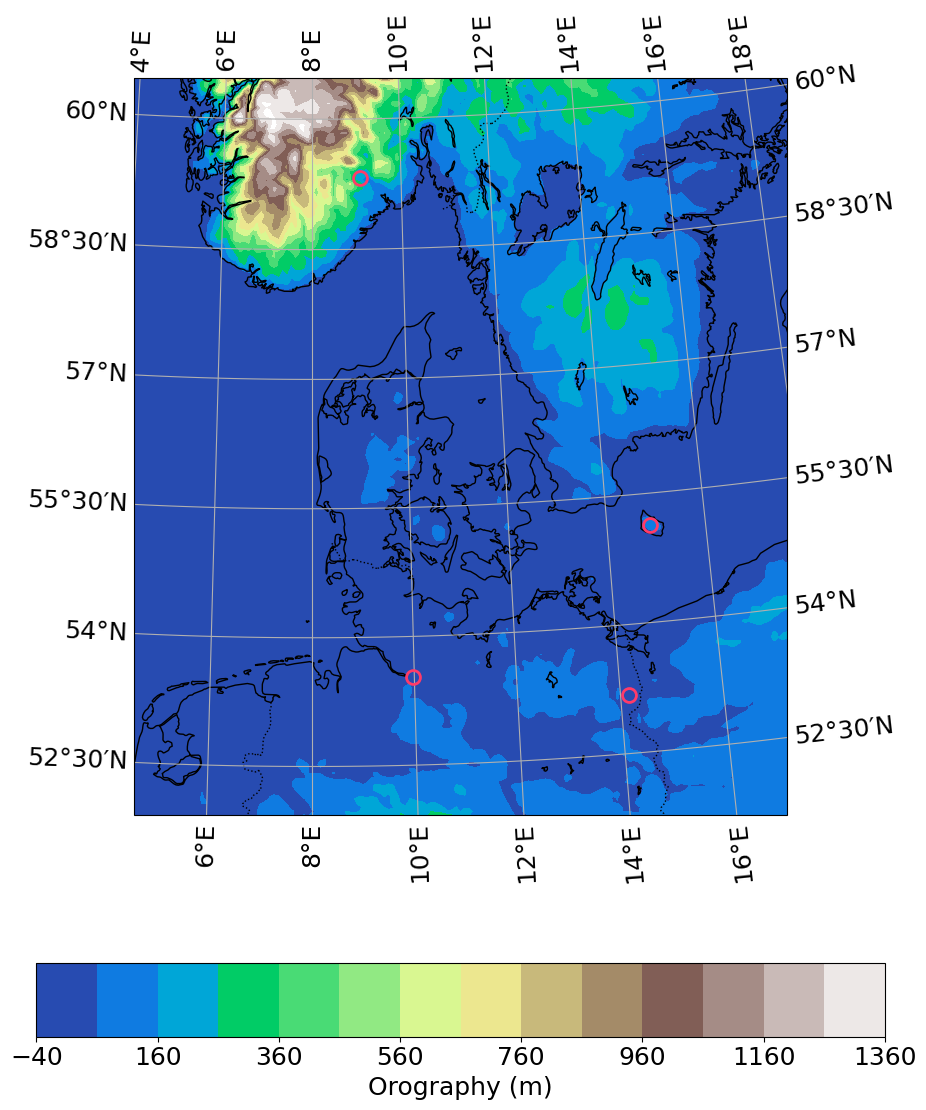

In [ ]:
# Load orography data
orog = xr.open_dataset('../data/CERRA-ERA5/cerra_const_sfc_variables.nc4c', engine='netcdf4')['orog']

# If comparing with Swin2SR, crop the spatial dimensions of orog
if compare_w_swin2sr:
    orog = orog[:, 40:215, 60:215]
    orog = xr.where(swin2sr.isel(time=0).expand_dims({'time':orog.time}).isnull(), np.nan, orog)

# If comparing with a model that does sea-masking, apply sea mask
if sea_masking:
    border_color = 'k'
    orog = xr.where(lsm < .01, np.nan, orog)
else:
    border_color = 'white'

# Projection and coordinates
transformer = Transformer.from_crs(
   "EPSG:4326",  # WGS84 lon/lat
   "+proj=lcc +lat_0=50 +lon_0=8 +lat_1=50 +lat_2=50 +R=6371229 +units=m",
   always_xy=True
)

lon0 = ds['Lambert_Conformal'].attrs['longitudeOfFirstGridPointInDegrees']
lat0 = ds['Lambert_Conformal'].attrs['latitudeOfFirstGridPointInDegrees']

x0, y0 = transformer.transform(lon0, lat0)

lambert_proj = ccrs.LambertConformal(
   central_longitude=8,
   central_latitude=50,
   standard_parallels=(50, 50),
   globe=ccrs.Globe(ellipse='sphere', semimajor_axis=6371229.0),
   false_easting=-x0,
   false_northing=-y0
)

x = orog.x
y = orog.y

# Create figure with map projection
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': lambert_proj})

# Plot the data
pcm = ax.contourf(x, y,
                  orog[0,:,:],   
                  levels=range(int(orog[0,:,:].min()/10)*10, int(orog[0,:,:].max()/10)*10, 100),  
                  cmap='terrain',
                  transform=lambert_proj)

# Add map features
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.coastlines(color=border_color)
ax.add_feature(cartopy.feature.BORDERS, ec=border_color, linestyle=':')
ax.add_feature(cartopy.feature.LAKES, fc='#00000000', ec=border_color) # type: ignore

# Add study points
for i in range(nb_points):
    x_pt, y_pt = transformer.transform(study_points['lon'][i], study_points['lat'][i])
    study_points.at[i, 'x'] = x_pt-x0
    study_points.at[i, 'y'] = y_pt

ax.scatter(study_points['x'], study_points['y'],
         fc='#00000000', s=100, marker='o', lw=2, ec="#FF3B69",
         transform=lambert_proj, zorder=10)

# Add colorbar
cax = ax.inset_axes((-.15, -.3, 1.3, .1))
plt.colorbar(pcm, cax = cax, orientation="horizontal", label='Orography (m)')

# Add title
# plt.title(f'CERRA Orography and study points')

plt.tight_layout()
plt.show()

### Distribution of Tmax

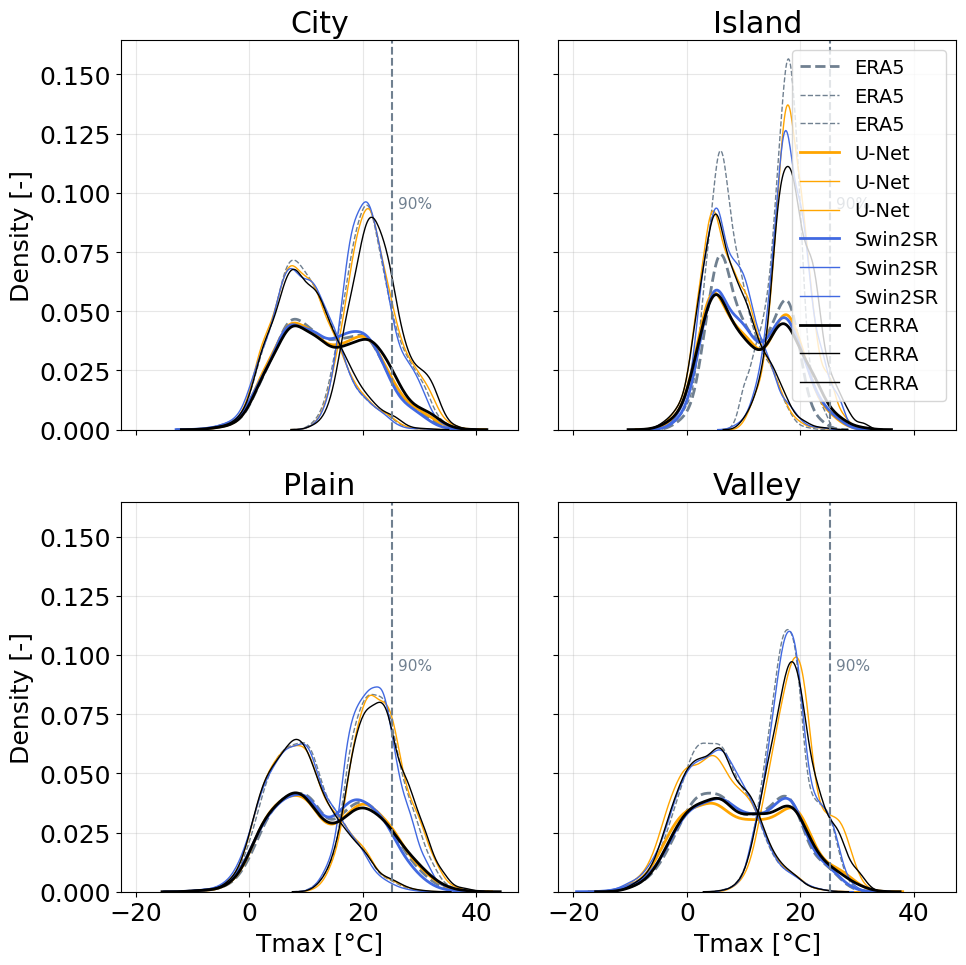

In [ ]:
ts_points = []

# To visualize summer and non-summer peaks separately
# ts_points_s = []
# ts_points_w = []

winter_times = [slice(f'{year}-09-15', f'{year+1}-05-15') for year in range(2014, 2021)]

for i in range(nb_points):
    ts_point = []
    for model in [truth] + models:
        ts_point.append(model.sel({'x': study_points['x'][i], 'y': study_points['y'][i]}, method='nearest'))
    ts_points.append(ts_point)

# for i in range(nb_points):
#     ts_point = []
#     for model in [truth] + models:
#         ts_model = []
#         for summer_time in summer_times:
#             ts_model.append(model.sel({'x': study_points['x'][i], 'y': study_points['y'][i]}, method='nearest').sel(time=summer_time))
#         ts_point.append(xr.concat(ts_model, dim='time'))
#     ts_points_s.append(ts_point)

# for i in range(nb_points):
#     ts_point = []
#     for model in [truth] + models:
#         ts_model = []
#         for winter_time in winter_times:
#             ts_model.append(model.sel({'x': study_points['x'][i], 'y': study_points['y'][i]}, method='nearest').sel(time=winter_time))
#         ts_point.append(xr.concat(ts_model, dim='time'))
#     ts_points_w.append(ts_point)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharex=True, sharey=True)

# For histplot
bmin, bmax = [ts_points[i][0].min().item() for i in range(nb_points)], [ts_points[i][0].max().item() for i in range(nb_points)]

for i in range(nb_points):
    axs[1, i%2].set_xlabel('Tmax [°C]')
    axs[i//2, 0].set_ylabel('Density [-]')
    ax = axs[i // 2, i % 2]
    
    for j in range(nb_models):
        # sns.histplot(data=ts_points[i][j+1], ax=ax, stat='density', binwidth=2, binrange=(bmin[i], bmax[i]), color=color_models[j], 
        #              element='step', alpha=.4 if j!=0 else 1, lw=0 if j!=0 else 2, fill=j!=0, label=name_models[j])
        sns.kdeplot(data=ts_points[i][j+1], ax=ax, color=color_models[j], label=name_models[j], lw=2, ls='--' if j==0 else '-')
        # sns.kdeplot(data=ts_points_s[i][j+1], ax=ax, color=color_models[j], label=name_models[j], lw=1, ls='--' if j==0 else '-')
        # sns.kdeplot(data=ts_points_w[i][j+1], ax=ax, color=color_models[j], label=name_models[j], lw=1, ls='--' if j==0 else '-')
        # ax.axvline(x=ts_points[i][j+1].mean(), ymin=0, ymax=50, ls='--', color=color_models[j])

    # sns.histplot(data=ts_points[i][0], ax=ax, stat='density', binwidth=2, binrange=(bmin[i], bmax[i]), element='step', lw=2, fill=False, label=name_truth, color=color_truth)
    sns.kdeplot(ts_points[i][0], ax=ax, color=color_truth, label=name_truth, lw=2)
    # sns.kdeplot(ts_points_s[i][0], ax=ax, color=color_truth, label=name_truth, lw=1)
    # sns.kdeplot(ts_points_w[i][0], ax=ax, color=color_truth, label=name_truth, lw=1)
    # ax.axvline(x=ts_points[i][0].mean(), ymin=0, ymax=50, ls='--', color=color_truth)
    
    axs[i//2, 1].get_yaxis().set_label_text('')
    ax.set_title(study_points['feature'][i])
    if i==nb_points//2-1: ax.legend(fontsize=14, loc='upper right')
    ax.grid(True, alpha=0.3)

    thresholds = [.9]
    for i, t in enumerate(thresholds):
        value = np.quantile(ts_points[i][0], t)
        ax.axvline(x=value, ls='--', color='slategrey')
        trans = mtr.blended_transform_factory(ax.transData, ax.transAxes)
        ax.text(x=value+1, y=.6-.05*i, s=str(int(t*100))+'%', c='slategrey', ha='left', va='top', fontsize=11, transform=trans)

# fig.suptitle('Tmax distributions')
plt.tight_layout()
plt.show()


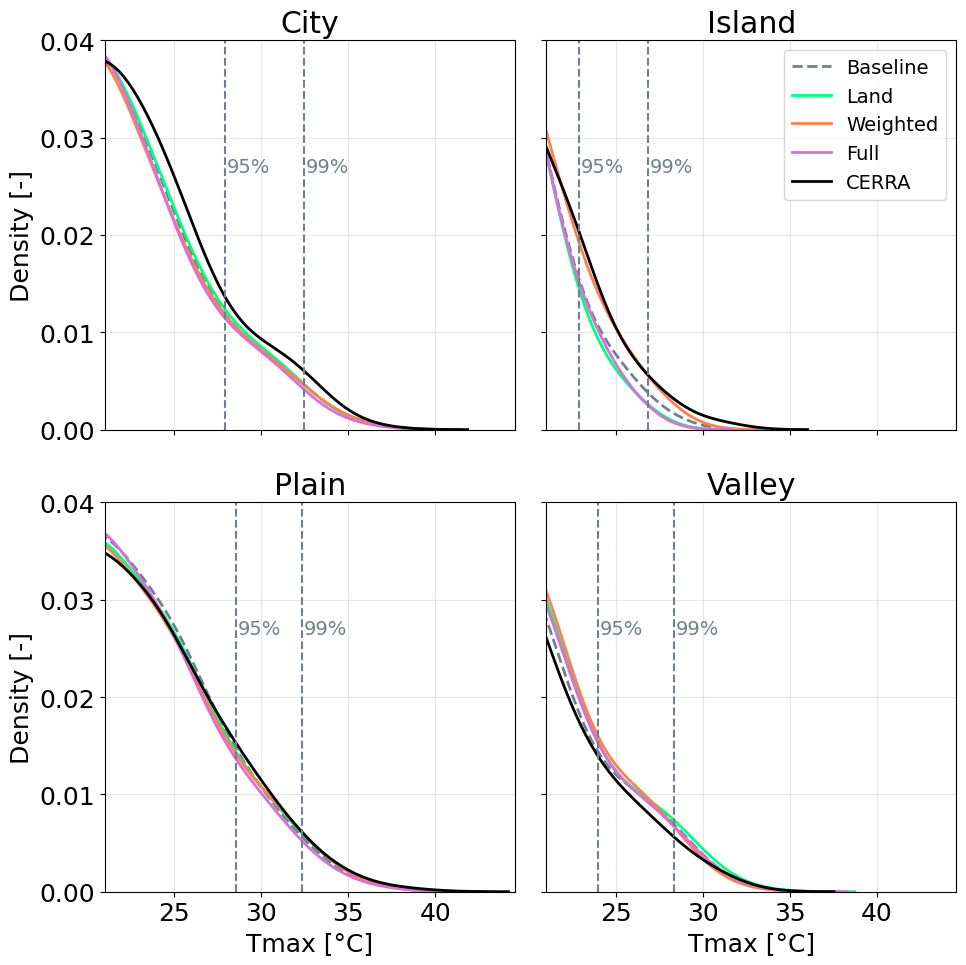

In [19]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharey=True, sharex=True)

for i in range(nb_points):
    axs[1, i%2].set_xlabel('Tmax [°C]')
    axs[i//2, 0].set_ylabel('Density [-]')
    ax = axs[i // 2, i % 2]
    
    for j in range(nb_models):
        # sns.histplot(data=ts_points[i][j+1], ax=ax, stat='density', binwidth=1, binrange=(bmin[i], bmax[i]), color=color_models[j], element='step', alpha=.4, lw=0, fill=j!=0)
        sns.kdeplot(data=ts_points[i][j+1], ax=ax, color=color_models[j], label=name_models[j], lw=2, ls='--' if j==0 else '-')

    # sns.histplot(data=ts_points[i][0], ax=ax, stat='density', binwidth=1, binrange=(bmin[i], bmax[i]), element='step', lw=0, fill=False)
    sns.kdeplot(ts_points[i][0], ax=ax, color=color_truth, label=name_truth, lw=2)
    
    axs[i//2, 1].get_yaxis().set_label_text('')
    ax.set_title(study_points['feature'][i])
    if i==nb_points//2-1: ax.legend(fontsize=14, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=min([ts_points[j][0].quantile(0.9) for j in range(nb_points)]))
    ax.set_ylim(0, .04) # Adjust by hand

    thresholds = [.95, .99]
    for t in thresholds:
        ax.axvline(x=ts_points[i][0].quantile(t), ls='--', color='slategrey')
        ax.text(x=ts_points[i][0].quantile(t) + 0.1, y=ax.get_ylim()[1]*.7, s=str(int(t*100))+'%', ha='left', va='top', fontsize=14, c='slategrey')

# fig.suptitle('Tmax distributions tails (>90th percentile)')
plt.tight_layout()
plt.show()

### Timeseries

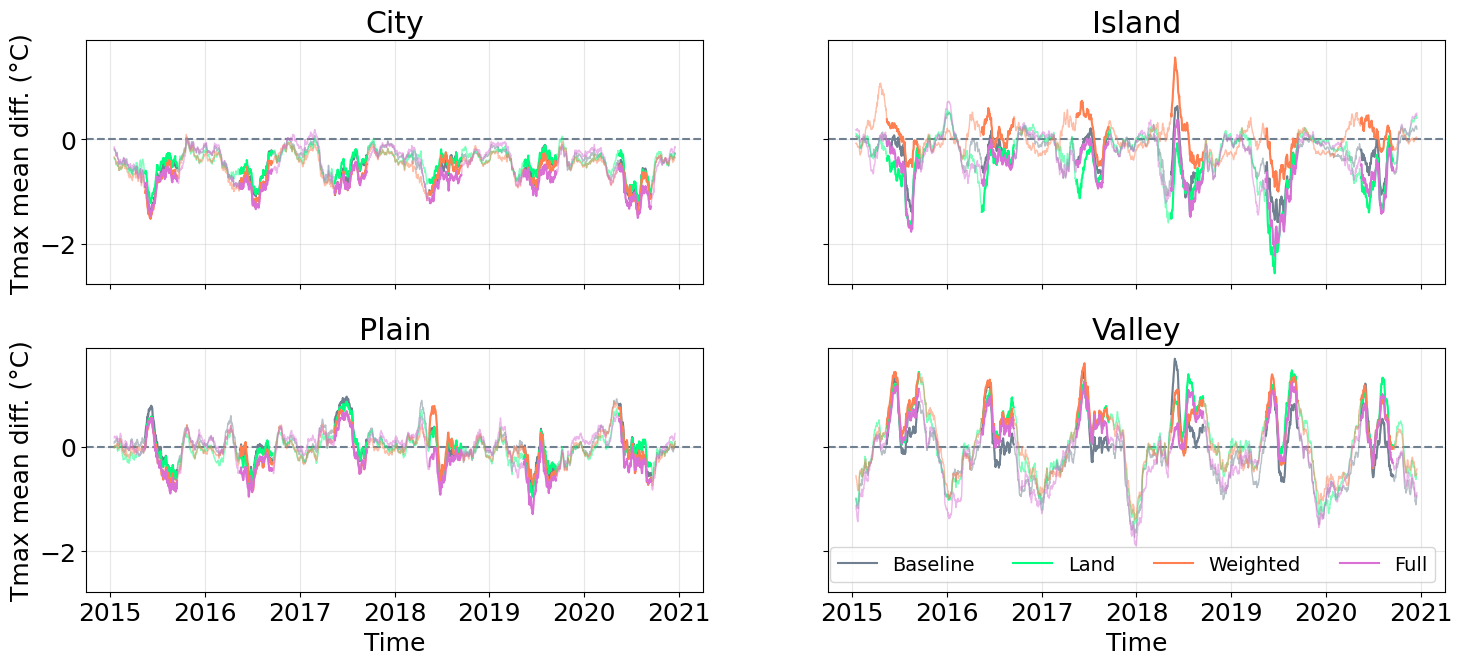

In [20]:
rolling = 30

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 7), sharex=True, sharey=True)

for i in range(nb_points):
    axs[1, i%2].set_xlabel('Time')
    axs[i//2, 0].set_ylabel('Tmax mean diff. (°C)')
    ax = axs[i // 2, i % 2]
    ax.axhline(y=0, ls='--', color='slategrey')
    for j in range(nb_models):
        ax.plot(ts_points[i][j+1].time, (ts_points[i][j+1]-ts_points[i][0]).rolling(time=rolling, center=True).mean(), 
                color=color_models[j], alpha=.5, lw=1)
        for k in range(nb_years):
            if i == nb_points-1 and k == 0:
                ax.plot(ts_points[i][j+1].sel(time=summer_times[k]).time, (ts_points[i][j+1]-ts_points[i][0]).rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), 
                        color=color_models[j], label=name_models[j])
            else:
                ax.plot(ts_points[i][j+1].sel(time=summer_times[k]).time, (ts_points[i][j+1]-ts_points[i][0]).rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), 
                        color=color_models[j])

    ax.set_title(study_points['feature'][i])
    ax.grid(True, alpha=0.3)
    if i==nb_points-1: ax.legend(fontsize=14, loc='lower right', ncol=4)
# fig.suptitle(f'Mean difference vs. CERRA ({rolling}-day rolling average)')
plt.tight_layout()
plt.show()

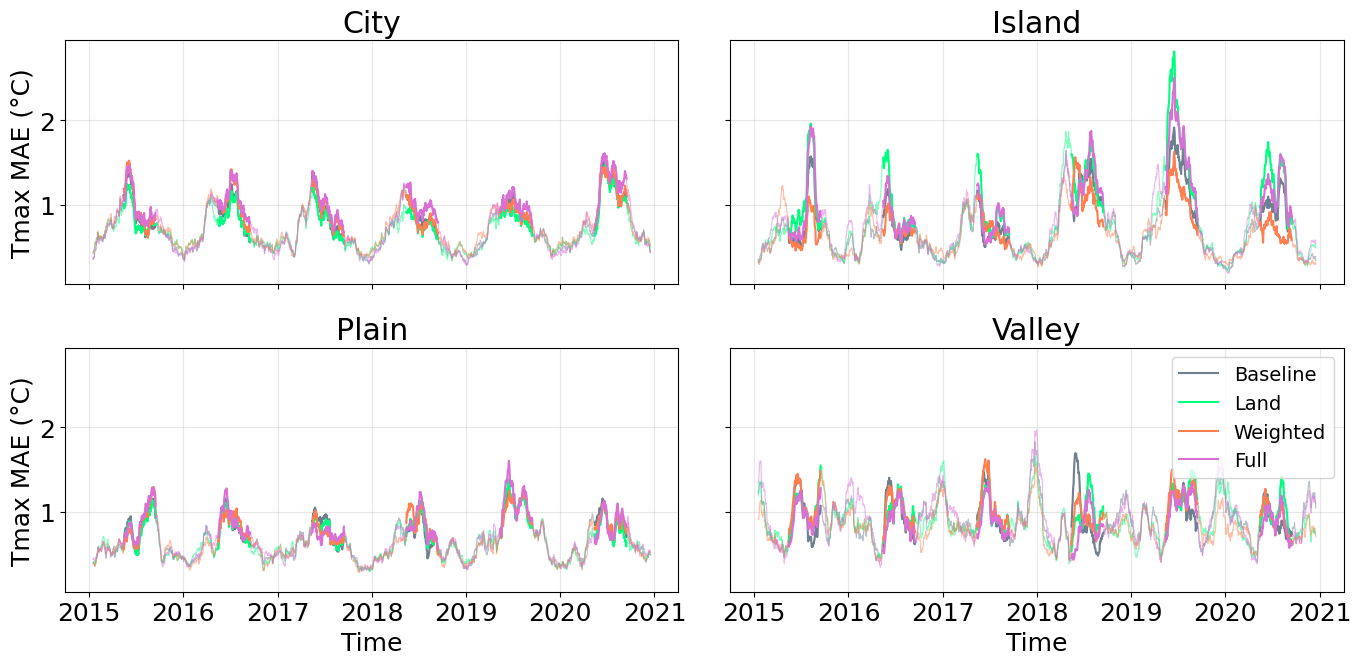

In [21]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 7), sharex=True, sharey=True)

for i in range(nb_points):
    axs[1, i%2].set_xlabel('Time')
    axs[i//2, 0].set_ylabel('Tmax MAE (°C)')
    ax = axs[i // 2, i % 2]
    for j in range(nb_models):
        ax.plot(ts_points[i][j+1].time, (np.abs(ts_points[i][j+1]-ts_points[i][0])).rolling(time=rolling, center=True).mean(), 
                color=color_models[j], alpha=.5, lw=.8)
        for k in range(nb_years):
            if i == nb_points-1 and k == 0:
                ax.plot(ts_points[i][j+1].sel(time=summer_times[k]).time, (np.abs(ts_points[i][j+1]-ts_points[i][0])).rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), 
                        color=color_models[j], label=name_models[j])
            else:
                ax.plot(ts_points[i][j+1].sel(time=summer_times[k]).time, (np.abs(ts_points[i][j+1]-ts_points[i][0])).rolling(time=rolling, center=True).mean().sel(time=summer_times[k]), 
                        color=color_models[j])
    ax.set_title(study_points['feature'][i])
    if i==nb_points-1: ax.legend(fontsize=14, loc='upper right')
    ax.grid(True, alpha=0.3)

# fig.suptitle(f'MSE vs. CERRA ({rolling}-day rolling average)')
plt.tight_layout()
plt.show()

## Spectral analysis

In [22]:
from compute_spectrum import compute_spectrum2d

def largest_nan_free_rectangle(data):
    """
    Find the largest rectangle containing no NaNs in a 3D array (time, y, x).
    
    Parameters:
    -----------
    data : ndarray, shape (time, y, x)
        Input array with potential NaNs
    
    Returns:
    --------
    (y_start, y_end, x_start, x_end) : tuple of int
        Indices defining the largest rectangle with no NaNs across all time steps
    """
    # Create a mask: True where valid data exists across ALL time steps
    valid_mask = ~np.isnan(data).any(axis=0)  # shape (y, x)
    
    ny, nx = valid_mask.shape
    
    # Convert to binary: 1 for valid, 0 for NaN
    binary = valid_mask.astype(int)
    
    # Build height matrix (for each column, height of consecutive 1s from top)
    height = np.zeros_like(binary)
    for i in range(ny):
        for j in range(nx):
            if binary[i, j] == 1:
                height[i, j] = 1 if i == 0 else height[i-1, j] + 1
            else:
                height[i, j] = 0
    
    # Find maximum rectangle using histogram method for each row
    max_area = 0
    best_rect = (0, 0, 0, 0)
    
    for i in range(ny):
        rect = largest_rectangle_in_histogram(height[i, :], i)
        if rect[4] > max_area:  # rect[4] is area
            max_area = rect[4]
            best_rect = rect[:4]
    
    return best_rect

def largest_rectangle_in_histogram(heights, row_idx):
    """
    Find largest rectangle in a histogram using stack-based algorithm.
    
    Returns: (y_start, y_end, x_start, x_end, area)
    """
    stack = []
    max_area = 0
    best_rect = (0, 0, 0, 0, 0)
    
    for i, h in enumerate(heights):
        start = i
        while stack and stack[-1][1] > h:
            idx, height = stack.pop()
            area = height * (i - idx)
            if area > max_area:
                max_area = area
                y_end = row_idx + 1
                y_start = row_idx - height + 1
                best_rect = (y_start, y_end, idx, i, area)
            start = idx
        stack.append((start, h))
    
    # Process remaining items in stack
    for idx, height in stack:
        area = height * (len(heights) - idx)
        if area > max_area:
            max_area = area
            y_end = row_idx + 1
            y_start = row_idx - height + 1
            best_rect = (y_start, y_end, idx, len(heights), area)
    
    return best_rect

if compare_w_swin2sr:
    # New crop to avoid NaNs
    y_start, y_end, x_start, x_end = largest_nan_free_rectangle(truth)
    print(f"Largest NaN-free rectangle: [{y_start}:{y_end}, {x_start}:{x_end}]")
    truth = truth[:, y_start:y_end, x_start:x_end]
    for i in range(len(models)):
        models[i] = models[i][:, y_start:y_end, x_start:x_end]

Computing for CERRA
Computing for Baseline
Computing for Land
Computing for Weighted
Computing for Full


<Figure size 640x480 with 0 Axes>

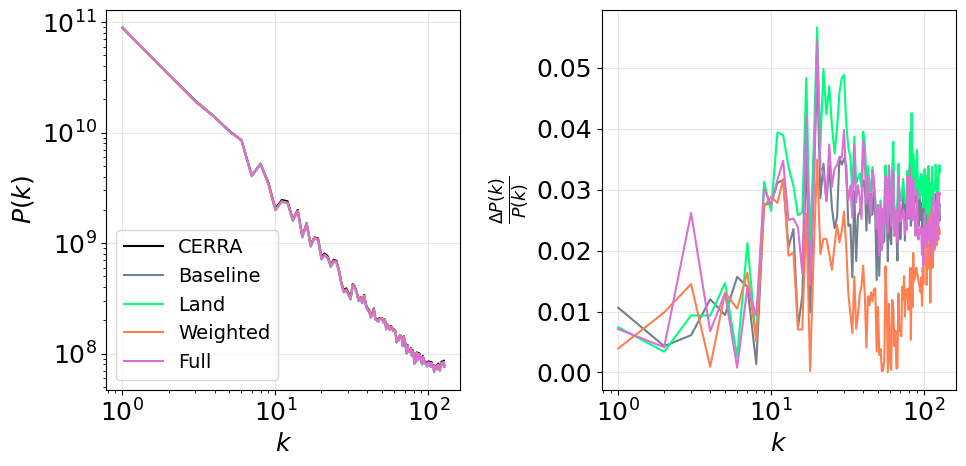

In [23]:
# plot_dir = "../output/plots/"
year_start = 2015
year_end = 2020

# Set up plot
plt.clf()
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

spectrum_all = {}

print(f'Computing for {name_truth}')
spectrum_all[name_truth] = {}

truth0 = xr.where(truth.isnull(), 0, truth)
data = truth0.to_numpy()

# Compute spectrum
kvals, Abins = compute_spectrum2d(data)
spectrum_all[name_truth] = Abins

axs[0].loglog(kvals, Abins,
                color=color_truth,
                label=name_truth,)
# plt.title(plot_varnames[i])
axs[0].set_xlabel("$k$")
axs[0].set_ylabel("$P(k)$")

for m, model in enumerate(models):
    print(f'Computing for {name_models[m]}')
    spectrum_all[name_models[m]] = {}

    model0 = xr.where(model.isnull(), 0, model)
    data = model0.to_numpy()

    # Compute spectrum
    kvals, Abins = compute_spectrum2d(data)
    spectrum_all[name_models[m]] = Abins

    axs[0].loglog(kvals, Abins,
                    color=color_models[m],
                    label=name_models[m])

    rel_diff = np.abs(spectrum_all[name_truth] - Abins)/spectrum_all[name_truth]
    axs[1].semilogx(kvals, rel_diff,
                    color=color_models[m])
    axs[1].set_xlabel("$k$")
    axs[1].set_ylabel("$\\frac{\\Delta P(k)}{P(k)}$")
    axs[0].legend(fontsize=14, loc='lower left')
    axs[0].grid(True, alpha=0.3)
    axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [24]:
data.shape[1]//2


128